In [1]:
import os
import copy
import random
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms

import os
import pandas as pd
import torch
from torch.utils.data import Dataset
from PIL import Image

from sklearn.metrics import roc_auc_score

from torch.nn import Dropout

# -------------------------
# Device
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Change list:
### 1. More wider channel sizes/ model width
### 2. Didn't downsize the images as much; 320x320 rather than 224x224
### 3. Keep stride = 1 for earlier layers
### 4. batchnorm, maxpool, and additional convolutions
### 5. Slower learning rate: 0.0001

In [2]:
def scan_available_files(image_folders):
    """
    Returns a set of filenames present in the provided image folders.
    image_folders should point to the actual image dirs
    (e.g. "images_001/images", not just "images_001").
    """
    available = set()
    for folder in image_folders:
        if not os.path.isdir(folder):
            raise ValueError(f"[scan_available_files] Not a directory: {folder}")

        for fn in os.listdir(folder):
            if fn.lower().endswith((".png", ".jpg", ".jpeg")):
                available.add(fn)
    return available


def build_patient_splits(
    csv_path,
    filename_col="Image Index",
    patient_col="Patient ID",
    train_folders=None,
    val_folders=None,
    test_folders=None,
    seed=42,
):
    """
    Split patients first, then filter each split to files that actually exist
    in the corresponding image folders.

    This follows the code.py logic exactly:
      1) shuffle unique patients
      2) assign 70/15/15 patient-level train/val/test splits
      3) pull all rows for patients in each split
      4) filter each split by filenames that exist in the provided folders
    """
    if not (train_folders and val_folders and test_folders):
        raise ValueError("Need folder lists for train_folders, val_folders, and test_folders.")

    df = pd.read_csv(csv_path)
    df[filename_col] = df[filename_col].astype(str).str.strip()

    # 1) Split at the PATIENT level
    all_patients = df[patient_col].unique()
    rng = np.random.default_rng(seed)
    rng.shuffle(all_patients)

    n = len(all_patients)
    n_train = int(0.7 * n)
    n_val = int(0.15 * n)

    train_patients = set(all_patients[:n_train])
    val_patients = set(all_patients[n_train:n_train + n_val])
    test_patients = set(all_patients[n_train + n_val:])

    # 2) Pull ALL rows for patients in each split
    df_train = df[df[patient_col].isin(train_patients)].copy()
    df_val = df[df[patient_col].isin(val_patients)].copy()
    df_test = df[df[patient_col].isin(test_patients)].copy()

    # 3) Filter by files that actually exist in each folder group
    train_files = scan_available_files(train_folders)
    val_files = scan_available_files(val_folders)
    test_files = scan_available_files(test_folders)

    df_train = df_train[df_train[filename_col].isin(train_files)].reset_index(drop=True)
    df_val = df_val[df_val[filename_col].isin(val_files)].reset_index(drop=True)
    df_test = df_test[df_test[filename_col].isin(test_files)].reset_index(drop=True)

    # Sanity checks
    train_pids = set(df_train[patient_col].unique())
    val_pids = set(df_val[patient_col].unique())
    test_pids = set(df_test[patient_col].unique())

    print("[Split rows] train/val/test:", len(df_train), len(df_val), len(df_test))
    print("[Unique patients] train/val/test:", len(train_pids), len(val_pids), len(test_pids))
    print(
        "[Overlaps] train∩val:", len(train_pids & val_pids),
        "train∩test:", len(train_pids & test_pids),
        "val∩test:", len(val_pids & test_pids),
    )

    return df_train, df_val, df_test


In [3]:
import numpy as np

def add_binary_label_column(df, finding_col="Finding Labels", out_col="binary_label"):
    """
    Adds a column with values: 'Healthy' if Finding Labels == 'No Finding' else 'Diseased'
    """
    df = df.copy()
    raw = df[finding_col].astype(str).str.strip()
    df[out_col] = np.where(raw == "No Finding", "Healthy", "Diseased")
    return df


def balance_50_50(df, label_col="binary_label", seed=42, method="undersample"):
    """
    Enforce 50/50 class balance between Healthy and Diseased.

    method:
      - 'undersample': downsample majority class to match minority (no duplicates)
      - 'oversample' : upsample minority class to match majority (adds duplicates)
    """
    rng = np.random.default_rng(seed)

    df = df.copy()
    counts = df[label_col].value_counts()
    if len(counts) < 2:
        raise ValueError(f"[balance_50_50] Need both classes present. Counts: {counts.to_dict()}")

    df_h = df[df[label_col] == "Healthy"]
    df_d = df[df[label_col] == "Diseased"]

    n_h = len(df_h)
    n_d = len(df_d)

    if method == "undersample":
        n = min(n_h, n_d)
        df_h_bal = df_h.sample(n=n, replace=False, random_state=seed)
        df_d_bal = df_d.sample(n=n, replace=False, random_state=seed)

    elif method == "oversample":
        n = max(n_h, n_d)
        df_h_bal = df_h.sample(n=n, replace=(n > n_h), random_state=seed)
        df_d_bal = df_d.sample(n=n, replace=(n > n_d), random_state=seed)

    else:
        raise ValueError("method must be 'undersample' or 'oversample'")

    df_bal = (
        np.random.permutation(pd.concat([df_h_bal, df_d_bal], axis=0).index)
    )
    # Shuffle rows
    out = pd.concat([df_h_bal, df_d_bal], axis=0).loc[df_bal].reset_index(drop=True)

    # sanity print
    print("[balance_50_50] after:", out[label_col].value_counts().to_dict())
    return out

In [4]:
import torch
from PIL import Image

class CSVDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        csv_path,
        image_folders,
        tfms=None,
        filename_col="Image Index",
        label_col="Finding Labels",
        patient_col="Patient ID",
        df_override=None,
        verbose=False,
    ):
        # ---- Load dataframe ----
        if df_override is not None:
            self.df = df_override.copy()
        else:
            self.df = pd.read_csv(csv_path)

        # Clean filename col to avoid whitespace mismatches
        self.df[filename_col] = self.df[filename_col].astype(str).str.strip()

        self.transform = tfms
        self.filename_col = filename_col
        self.label_col = label_col
        self.patient_col = patient_col

        # Normalize folder input
        if isinstance(image_folders, str):
            self.image_dirs = [image_folders]
        else:
            self.image_dirs = list(image_folders)

        # Build filename -> full path map
        self.path_map = {}
        total_files_found = 0

        for d in self.image_dirs:
            if not os.path.isdir(d):
                raise ValueError(f"[CSVDataset] Image directory not found: {d}")

            for f in os.listdir(d):
                if not f.lower().endswith((".png", ".jpg", ".jpeg")):
                    continue

                full = os.path.join(d, f)
                if os.path.isfile(full):
                    total_files_found += 1
                    if f not in self.path_map:
                        self.path_map[f] = full

        available_files = set(self.path_map.keys())

        before = len(self.df)
        self.df = self.df[self.df[filename_col].isin(available_files)].reset_index(drop=True)
        after = len(self.df)

        if verbose:
            print(f"[CSVDataset] Loaded CSV rows: {before}")
            print(f"[CSVDataset] Image folders: {self.image_dirs}")
            print(f"[CSVDataset] Total image files scanned: {total_files_found}")
            print(f"[CSVDataset] Unique filenames available: {len(available_files)}")
            print(f"[CSVDataset] Kept rows with existing images: {after}")
            print(f"[CSVDataset] Dropped rows missing images: {before - after}")

        if len(self.df) == 0:
            raise ValueError(
                "[CSVDataset] Dataset is empty after filtering.\n"
                "Most likely causes:\n"
                " - wrong folder paths (must point to .../images)\n"
                " - filename_col mismatch (expected 'Image Index')\n"
                " - filenames in CSV don't match actual files (whitespace/extension)\n"
            )

        # Label mapping
        self.label_to_idx = None
        if self.label_col is not None:
            if self.label_col == "Finding Labels":
                # binary
                self.label_to_idx = {"Healthy": 0, "Diseased": 1}
            else:
                labels = sorted(self.df[self.label_col].unique())
                self.label_to_idx = {lab: i for i, lab in enumerate(labels)}

            if verbose:
                print(f"[CSVDataset] label_to_idx: {self.label_to_idx}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = row[self.filename_col]

        path = self.path_map.get(filename)
        if path is None:
            raise FileNotFoundError(f"[CSVDataset] Missing file at runtime: {filename}")

        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        pid = str(row[self.patient_col]).strip()

        if self.label_col is None:
            return img, pid

        if self.label_col == "Finding Labels":
            raw = str(row[self.label_col]).strip()
            label_str = "Healthy" if raw == "No Finding" else "Diseased"
            y = self.label_to_idx[label_str]
            return img, torch.tensor(y, dtype=torch.long), pid

        y = self.label_to_idx[row[self.label_col]]
        return img, torch.tensor(y, dtype=torch.long), pid

In [5]:
train_folders = ["images_001/images", "images_002/images", "images_003/images", "images_004/images", "images_005/images", "images_006/images", "images_007/images"]
val_folders   = ["images_008/images"]
test_folders  = ["images_009/images"]
csv_path = "Data_Entry_2017.csv"

train_tfms = transforms.Compose([
    transforms.Resize((320, 320)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

eval_tfms = transforms.Compose([
    transforms.Resize((320, 320)),
    transforms.ToTensor(),
])

train_df, val_df, test_df = build_patient_splits(
    csv_path=csv_path,
    filename_col="Image Index",
    patient_col="Patient ID",
    train_folders=train_folders,
    val_folders=val_folders,
    test_folders=test_folders,
)

# Add binary label to each split (for balancing + quick sanity checks)
train_df = add_binary_label_column(train_df, finding_col="Finding Labels", out_col="binary_label")
val_df   = add_binary_label_column(val_df,   finding_col="Finding Labels", out_col="binary_label")
test_df  = add_binary_label_column(test_df,  finding_col="Finding Labels", out_col="binary_label")

print("Before balancing train:", train_df["binary_label"].value_counts().to_dict())

# Balance TRAIN to 50/50
# Choose ONE:
train_df = balance_50_50(train_df, label_col="binary_label", seed=42, method="undersample")
# train_df = balance_50_50(train_df, label_col="binary_label", seed=42, method="oversample")

train_ds = CSVDataset(csv_path, train_folders, tfms=train_tfms, df_override=train_df, verbose=True)
val_ds   = CSVDataset(csv_path, val_folders,   tfms=eval_tfms,  df_override=val_df,  verbose=True)
test_ds  = CSVDataset(csv_path, test_folders,  tfms=eval_tfms,  df_override=test_df, verbose=True)

[Split rows] train/val/test: 45769 1444 1041
[Unique patients] train/val/test: 11198 351 402
[Overlaps] train∩val: 0 train∩test: 0 val∩test: 0
Before balancing train: {'Healthy': 25653, 'Diseased': 20116}
[balance_50_50] after: {'Healthy': 20116, 'Diseased': 20116}
[CSVDataset] Loaded CSV rows: 40232
[CSVDataset] Image folders: ['images_001/images', 'images_002/images', 'images_003/images', 'images_004/images', 'images_005/images', 'images_006/images', 'images_007/images']
[CSVDataset] Total image files scanned: 64999
[CSVDataset] Unique filenames available: 64999
[CSVDataset] Kept rows with existing images: 40232
[CSVDataset] Dropped rows missing images: 0
[CSVDataset] label_to_idx: {'Healthy': 0, 'Diseased': 1}
[CSVDataset] Loaded CSV rows: 1444
[CSVDataset] Image folders: ['images_008/images']
[CSVDataset] Total image files scanned: 10000
[CSVDataset] Unique filenames available: 10000
[CSVDataset] Kept rows with existing images: 1444
[CSVDataset] Dropped rows missing images: 0
[CSVD

In [6]:
print(train_ds.df['Patient ID'].nunique())
print(train_ds.df.shape[0])

10230
40232


In [7]:
pin = (device.type == "cuda")
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0, pin_memory=pin)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0, pin_memory=pin)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=0, pin_memory=pin)

In [9]:
class SimpleCNN2(nn.Module):
    """
    Simple CNN adapted for large images (e.g., 1024x1024):
    - Uses stride=2 convolutions (or pooling with stride=2) to downsample aggressively
    - Uses Global Average Pooling to avoid massive Flatten -> FC parameter explosion
    - Made wider (more channels) to increase capacity, since we have more data and a binary task
    - Add more convolutions per stage
    """
    def __init__(self, num_classes=10):
        super().__init__()

        # Downsample 1024 -> 512
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),  # (N,32,512,512)
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),  # (N,64,512,512)
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        # 512 -> 256
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), # (N,64,256,256)
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1), # (N,128,256,256)
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        # 256 -> 128
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1), # (N,128,128,128)
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1), # (N,256,128,128)
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        # 128 -> 64
        self.block4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, stride=2, padding=1), # (N,256,64,64)
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1), # (N,512,64,64)
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        # Global Average Pooling: (N,256,64,64) -> (N,256,1,1)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # Small classifier head
        self.classifier = nn.Sequential(
            nn.Flatten(),               # (N,256)
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

In [10]:
# Training configuration
NUM_EPOCHS = 20
LEARNING_RATE = 0.0001

# Loss function
criterion = nn.CrossEntropyLoss()
model2 = SimpleCNN2(num_classes=2).to(device)
optimizer2 = optim.Adam(model2.parameters(), lr=LEARNING_RATE)
scheduler2 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer2, mode='min', factor=0.5, patience=4
)

In [11]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels, _ in train_loader:   # ✅ unpack pid
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total  # keep as 0-1 fraction (recommended)
    return epoch_loss, epoch_acc

In [12]:
from sklearn.metrics import roc_auc_score

def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels, _ in loader:     # ✅ unpack pid
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            probs = torch.softmax(outputs, dim=1)[:, 1]
            all_probs.extend(probs.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    # AUC needs both classes present
    auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else float("nan")

    return epoch_loss, epoch_acc, auc

In [13]:
random.seed(5)
np.random.seed(5)
torch.manual_seed(5)
torch.cuda.manual_seed(5)
torch.cuda.manual_seed_all(5)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

EARLY_STOP_PATIENCE = 3
MIN_DELTA = 0.0

train_losses, train_accs = [], []
val_losses, val_accs     = [], []

best_val_auc = -float("inf")
best_epoch = -1
best_state = None
epochs_without_improve = 0

print("Starting training...")
print(f"{'Epoch':<8} {'Train Loss':<12} {'Train Acc':<12} {'Val Loss':<12} {'Val Acc':<12} {'Val AUC':<12}")
print("-" * 70)

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model2, train_loader, criterion, optimizer2, device)
    val_loss, val_acc, val_auc     = evaluate(model2, val_loader, criterion, device)

    scheduler2.step(val_loss)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    if val_auc > best_val_auc + MIN_DELTA:
        best_val_auc = val_auc
        best_epoch = epoch + 1
        best_state = copy.deepcopy(model2.state_dict())
        epochs_without_improve = 0
    else:
        epochs_without_improve += 1

    print(f"{epoch+1:<8} {train_loss:<12.4f} {train_acc:<12.2f} {val_loss:<12.4f} {val_acc:<12.2f} {val_auc:<12.4f}")  

    if epochs_without_improve >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping: val auc hasn't improved for {EARLY_STOP_PATIENCE} epoch(s).")
        break

print("\nTraining complete!")
print(f"Best Val AUC: {best_val_auc:.4f} at epoch {best_epoch}")

if best_state is not None:
    model2.load_state_dict(best_state)

Starting training...
Epoch    Train Loss   Train Acc    Val Loss     Val Acc      Val AUC     
----------------------------------------------------------------------
1        0.6569       0.61         0.7486       0.48         0.7229      
2        0.6290       0.66         0.6437       0.64         0.7348      
3        0.6174       0.67         0.5984       0.68         0.7446      
4        0.6108       0.68         0.6050       0.68         0.7531      
5        0.6059       0.68         0.6154       0.68         0.7491      
6        0.6014       0.69         0.6389       0.64         0.7328      
7        0.5965       0.69         0.5982       0.69         0.7525      

Early stopping: val auc hasn't improved for 3 epoch(s).

Training complete!
Best Val AUC: 0.7531 at epoch 4


In [14]:
test_loss, test_acc, test_auc = evaluate(model2, test_loader, criterion, device)
print("\nTest set results (best-val-AUC checkpoint):")
print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f} | Test AUC: {test_auc:.4f}")


Test set results (best-val-AUC checkpoint):
Test Loss: 0.6716 | Test Acc: 0.6177 | Test AUC: 0.6543


In [16]:
# Save best model parameters to disk
torch.save(best_state, "best_cnn_model_heavy.pth")
print("Model parameters saved to best_cnn_model_heavy.pth")

Model parameters saved to best_cnn_model_heavy.pth


In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, loader, device, class_names=("Healthy", "Diseased")):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels, _ in loader:   # same unpacking style as your notebook
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, values_format="d", cmap="Blues", colorbar=False)
    plt.title("Confusion Matrix - Test Set")
    plt.show()

    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    return cm, all_labels, all_preds

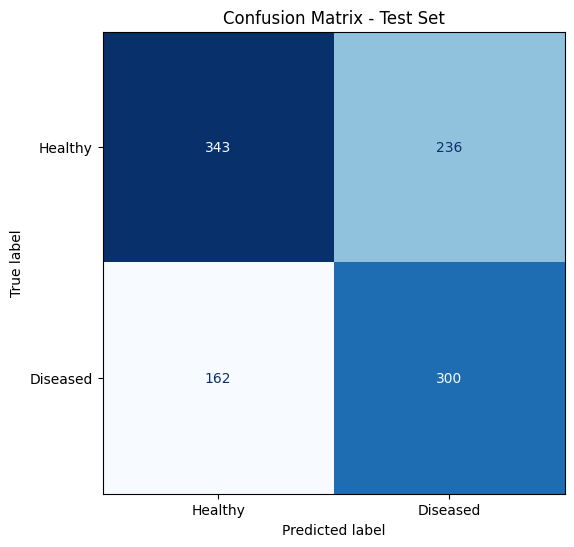

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.68      0.59      0.63       579
    Diseased       0.56      0.65      0.60       462

    accuracy                           0.62      1041
   macro avg       0.62      0.62      0.62      1041
weighted avg       0.63      0.62      0.62      1041



In [16]:
cm, y_true, y_pred = plot_confusion_matrix(
    model2,
    test_loader,
    device,
    class_names=("Healthy", "Diseased")
)

In [17]:
import matplotlib.pyplot as plt

def plot_training_curves(train_losses, val_losses, train_accs, val_accs):
    epochs = range(1, len(train_losses) + 1)

    # Loss curve
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_losses, label="Train Loss")
    plt.plot(epochs, val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Accuracy curve
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_accs, label="Train Accuracy")
    plt.plot(epochs, val_accs, label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

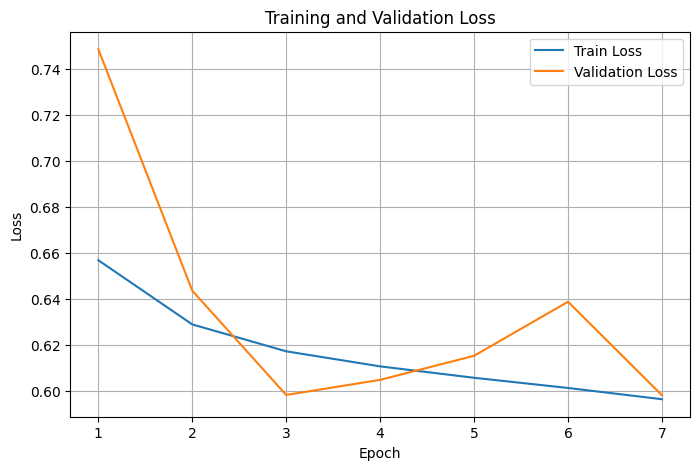

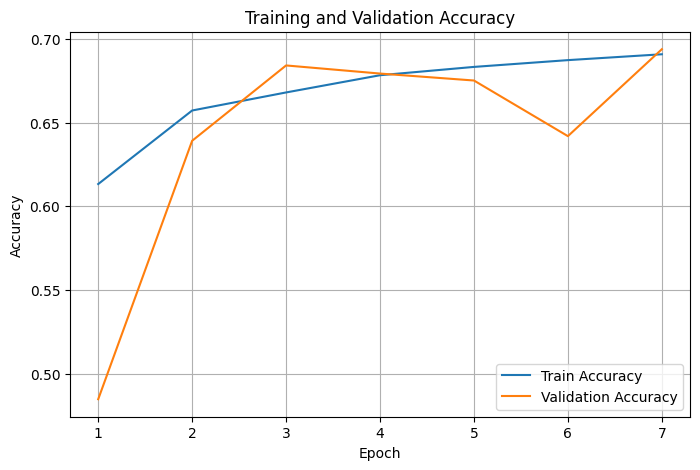

In [18]:
plot_training_curves(train_losses, val_losses, train_accs, val_accs)